# ch294 — Classification

*(Extends logistic regression from ch229; uses sigmoid from ch063; applies cross-entropy from ch287)*

## 1. The Classification Problem

Given features, predict a class label from a finite set. Classification is regression with a categorical output constrained to a probability simplex.

---

## 2. Logistic Regression from Scratch

Manual accuracy:  0.8500
Sklearn accuracy: 0.8500


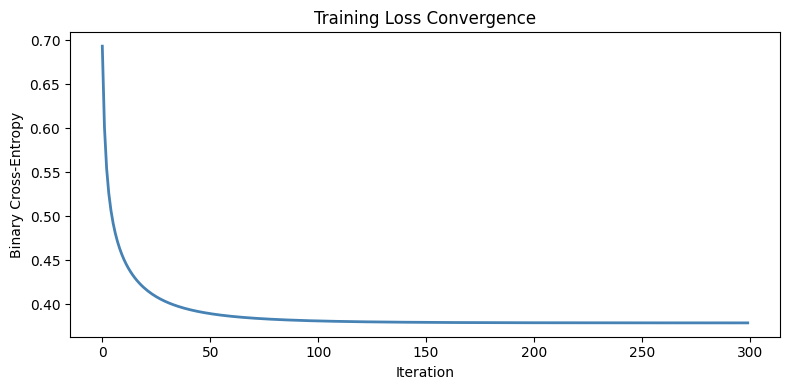

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

rng = np.random.default_rng(42)


def sigmoid(z):
    """Numerically stable sigmoid."""
    return np.where(z >= 0,
                    1 / (1 + np.exp(-z)),
                    np.exp(z) / (1 + np.exp(z)))


class LogisticRegressionScratch:
    """Binary logistic regression via gradient descent."""

    def __init__(self, lr=0.1, n_iter=500, lam=0.01):
        self.lr = lr
        self.n_iter = n_iter
        self.lam = lam
        self.w = None
        self.b = 0.0
        self.losses = []

    def fit(self, X, y):
        n, p = X.shape
        self.w = np.zeros(p)
        self.b = 0.0
        for _ in range(self.n_iter):
            z = X @ self.w + self.b
            y_hat = sigmoid(z)
            err = y_hat - y
            self.w -= self.lr * (X.T @ err / n + self.lam * self.w)
            self.b -= self.lr * err.mean()
            eps = 1e-15
            loss = -np.mean(
                y * np.log(np.clip(y_hat, eps, 1)) +
                (1 - y) * np.log(np.clip(1 - y_hat, eps, 1))
            )
            self.losses.append(loss)
        return self

    def predict_proba(self, X):
        return sigmoid(X @ self.w + self.b)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)


X, y = make_classification(n_samples=500, n_features=10, n_informative=5, random_state=42)
X = (X - X.mean(0)) / X.std(0)
X_tr, X_te = X[:-100], X[-100:]
y_tr, y_te = y[:-100], y[-100:]

model = LogisticRegressionScratch(lr=0.5, n_iter=300, lam=0.01)
model.fit(X_tr, y_tr)

acc = (model.predict(X_te) == y_te).mean()
lr_sk = LogisticRegression(C=1/0.01, max_iter=1000)
lr_sk.fit(X_tr, y_tr)
acc_sk = lr_sk.score(X_te, y_te)

print(f'Manual accuracy:  {acc:.4f}')
print(f'Sklearn accuracy: {acc_sk:.4f}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(model.losses, color='steelblue', lw=2)
ax.set_xlabel('Iteration'); ax.set_ylabel('Binary Cross-Entropy')
ax.set_title('Training Loss Convergence')
plt.tight_layout()
plt.show()

## 3. Decision Boundaries

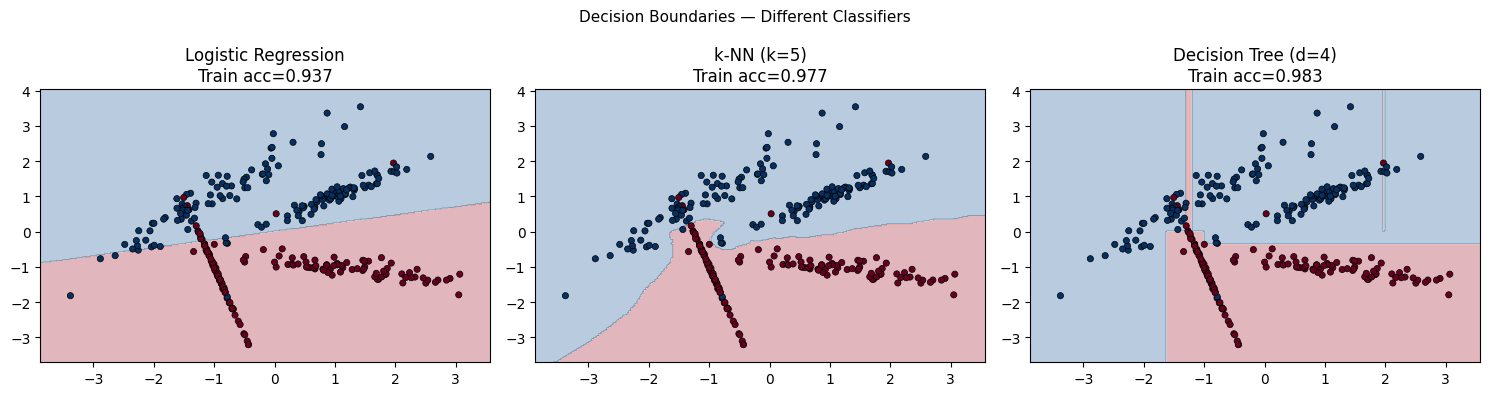

In [3]:
X_2d, y_2d = make_classification(
    n_samples=300, n_features=2, n_redundant=0, n_informative=2,
    random_state=0, n_clusters_per_class=2
)

classifiers = [
    ('Logistic Regression', LogisticRegression(C=1, max_iter=1000)),
    ('k-NN (k=5)',          KNeighborsClassifier(n_neighbors=5)),
    ('Decision Tree (d=4)', DecisionTreeClassifier(max_depth=4, random_state=0)),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
x0_min, x0_max = X_2d[:, 0].min() - 0.5, X_2d[:, 0].max() + 0.5
x1_min, x1_max = X_2d[:, 1].min() - 0.5, X_2d[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x0_min, x0_max, 300),
                      np.linspace(x1_min, x1_max, 300))

for ax, (name, clf) in zip(axes, classifiers):
    clf.fit(X_2d, y_2d)
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
    ax.scatter(X_2d[:, 0], X_2d[:, 1], c=y_2d, cmap='RdBu',
               edgecolors='k', s=20, lw=0.5)
    ax.set_title(f'{name}\nTrain acc={clf.score(X_2d, y_2d):.3f}')

plt.suptitle('Decision Boundaries — Different Classifiers', fontsize=11)
plt.tight_layout()
plt.show()

## 4. Softmax for Multiclass

In [4]:
def softmax(Z):
    """Numerically stable softmax over rows."""
    Z_shift = Z - Z.max(axis=1, keepdims=True)
    exp_Z = np.exp(Z_shift)
    return exp_Z / exp_Z.sum(axis=1, keepdims=True)

Z = np.array([[2.0, 1.0, 0.5],
              [1.0, 3.0, 0.1]])
probs = softmax(Z)

print('Softmax output:')
print(np.round(probs, 4))
print('Row sums (must be 1):', probs.sum(axis=1))
print()
print('Softmax + cross-entropy = standard multiclass classification loss.')
print('This is the output layer of any classification neural network.')

Softmax output:
[[0.6285 0.2312 0.1402]
 [0.1137 0.8401 0.0462]]
Row sums (must be 1): [1. 1.]

Softmax + cross-entropy = standard multiclass classification loss.
This is the output layer of any classification neural network.


## 5. What Comes Next

Logistic regression is a single linear layer followed by sigmoid/softmax. **ch295 — Neural Network Math Review** stacks these layers with non-linear activations and trains via backpropagation — the chain rule applied through the computation graph. The softmax + cross-entropy combination here is exactly the final layer of a classification neural network.